In [1]:
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt

In [2]:
def load_shape_file(path):
    sequence_ids = []
    rows = []
    current_vals = []
    current_id = None

    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith('>'):
                if current_id is not None:
                    rows.append(current_vals)
                current_id = line[1:]
                sequence_ids.append(current_id)
                current_vals = []
            else:
                vals = [float(x) if x != 'NA' else np.nan for x in line.split(',')]
                current_vals.extend(vals)

        if current_id is not None:
            rows.append(current_vals)

    df = pd.DataFrame(rows)
    df.index = sequence_ids
    return df

In [3]:
# HelT — Helical Twist
# orig = load_shape_file('/scratch1/smaruj/suppressing_CTCFs/results_repeated/original_preds/php26h8p4.HelT')
# edit = load_shape_file('/scratch1/smaruj/suppressing_CTCFs/results_repeated/edited_preds/phpiDvRMX.HelT')

# MGW — Minor Groove Width
# orig = load_shape_file('/scratch1/smaruj/suppressing_CTCFs/results_repeated/original_preds/php26h8p4.MGW')
# edit = load_shape_file('/scratch1/smaruj/suppressing_CTCFs/results_repeated/edited_preds/phpiDvRMX.MGW')

# Roll
# orig = load_shape_file('/scratch1/smaruj/suppressing_CTCFs/results_repeated/original_preds/php26h8p4.Roll')
# edit = load_shape_file('/scratch1/smaruj/suppressing_CTCFs/results_repeated/edited_preds/phpiDvRMX.Roll')

# ProT
orig = load_shape_file('/scratch1/smaruj/suppressing_CTCFs/results_repeated/original_preds/php26h8p4.ProT')
edit = load_shape_file('/scratch1/smaruj/suppressing_CTCFs/results_repeated/edited_preds/phpiDvRMX.ProT')

In [4]:
assert orig.shape == edit.shape

In [5]:
# Keep columns that have at least some non-NaN values
valid_cols = orig.notna().any(axis=0) & edit.notna().any(axis=0)

orig_clean = orig.loc[:, valid_cols]
edit_clean = edit.loc[:, valid_cols]

print(f"Using {orig_clean.shape[1]} / {orig.shape[1]} columns")

Using 2044 / 2048 columns


In [6]:
orig_mean = orig_clean.mean(axis=1)
edit_mean = edit_clean.mean(axis=1)

from scipy.stats import wilcoxon
stat, p = wilcoxon(orig_mean, edit_mean, nan_policy="omit")

effect_size = (edit_mean.mean() - orig_mean.mean()) / np.std(
    edit_mean - orig_mean, ddof=1
)

print(f"Paired Wilcoxon p = {p:.3e}")
print(f"Effect size (standardized Δ) = {effect_size:.2f}")


Paired Wilcoxon p = 8.387e-08
Effect size (standardized Δ) = nan


In [7]:
orig_var = orig_clean.var(axis=1)
edit_var = edit_clean.var(axis=1)

stat, p = wilcoxon(orig_var, edit_var, nan_policy="omit")

print(f"Variance comparison p = {p:.3e}")
print(f"Mean variance (original): {orig_var.mean():.3f}")
print(f"Mean variance (edited):   {edit_var.mean():.3f}")

Variance comparison p = 3.704e-04
Mean variance (original): 12.454
Mean variance (edited):   11.873


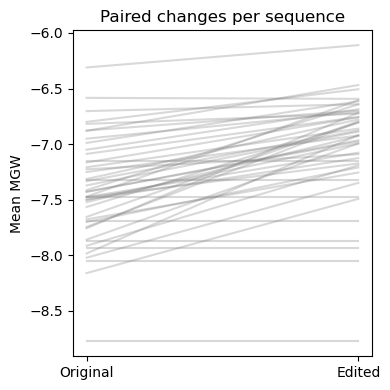

In [8]:
plt.figure(figsize=(4,4))
for o, e in zip(orig_mean, edit_mean):
    plt.plot([0, 1], [o, e], color="gray", alpha=0.3)

plt.xticks([0, 1], ["Original", "Edited"])
plt.ylabel("Mean MGW")
plt.title("Paired changes per sequence")
plt.tight_layout()
plt.show()
